# Post-hoc analysis from a saved inversion bundle

An inversion saved with `run_halo.py --save DIR` (or `save_inversion(...)`) can be reloaded and analyzed **without re-reading the Jacobian or re-solving** — aggregation and disaggregation are linear functionals of the posterior, and the bundle stores the factors that reproduce `aᵀx̂` and `aᵀŜa` exactly.

This notebook demonstrates the reader (`load_inversion` → `SavedInversion`) and useful plots:

1. Load + inspect the bundle
2. Posterior scalar fields and their uncertainty
3. Observation diagnostics (obs / background / enhancement / modeled / residual / outliers)
4. Model–data mismatch: normalized residuals, per-flight bias/RMS, along-track autocorrelation
5. The retrieved background offset(s)
6. Buffer region (out-of-core nuisance state): prior vs posterior super-cell fluxes
7. **Post-hoc re-aggregation with uncertainty**: domain total, regional sub-totals, and sector totals with their cross-covariance

Point `BUNDLE_DIR` at one of your real bundles to use real results; otherwise a small synthetic bundle (now including a buffer region) is built so the notebook runs anywhere.

In [ ]:
import os, sys, tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BAYES_OPT = os.path.dirname(os.path.dirname(os.path.abspath('saved_bundle_analysis.ipynb')))
if BAYES_OPT not in sys.path:
    sys.path.insert(0, BAYES_OPT)
import halo_oe  # noqa: F401

from halo_oe.io_bundle import load_inversion
from halo_oe.flux import cell_areas_m2
from halo_oe.plotting import plot_posterior,plot_residuals,plot_buffer_regions

# Set this to a real bundle directory (from `run_halo.py --save`) to analyze real
# results. Bundles now live under bayes_opt/runs/. If the path does not exist, a
# small synthetic bundle (with a buffer region) is built below.
BUNDLE_DIR_1 = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg1'))
BUNDLE_DIR_2 = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg2'))


## 5. Retrieved background offset(s)

One optimized offset per flight, on top of the fitted background plane.

In [7]:
if 'bc' in inv.state.names:
    bc = inv.block('bc'); bc_sd = inv.state.unpack(inv.posterior.stddev())['bc']
    for fid, v, s in zip(inv.flight_ids, bc, bc_sd):
        print(f'  background offset [{fid}]: {v:+.4f} +/- {s:.4f} ppm')
else:
    print('no background-offset block in this inversion')

  background offset [20230726_1]: +0.0307 +/- 0.0017 ppm


## 6. Buffer region (out-of-core nuisance state)

If the inversion enabled a coarse buffer, the bundle stores its super-cell geometry (`inv.buffer`) and the buffer block lives in the state vector. The buffer absorbs out-of-core emissions so they do not alias into the core edge; it is reported here for inspection but is **not** part of the core total. We compare each super-cell's **prior** flux (area-weighted inventory density) with its **posterior** ± 1σ, and map both.

buffer: 3258 super-cells over 308580 native cells (mode in config; geometry from the bundle)


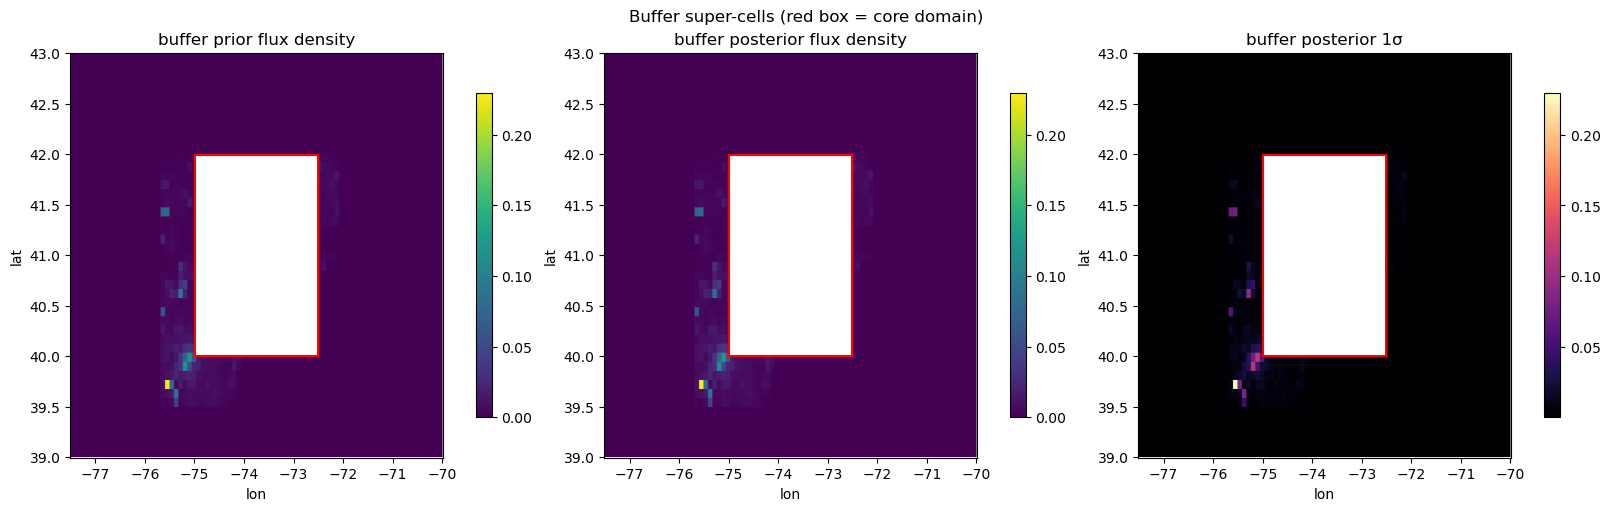

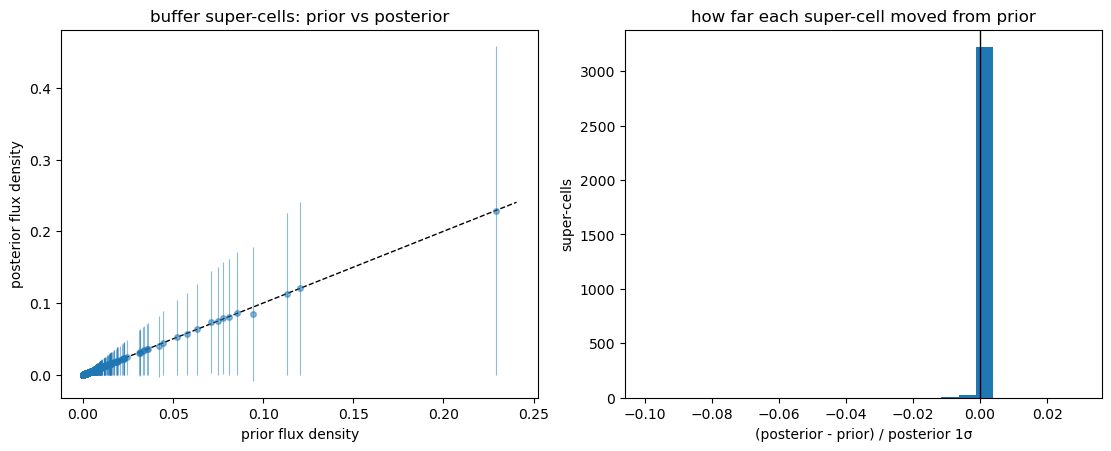

In [8]:
buf = inv.buffer
if buf is None or 'buffer' not in inv.state.names:
    print('no buffer region in this inversion (enable [buffer] in the config to use one)')
else:
    memb = np.asarray(buf['membership'])                       # (n_lat, n_lon), -1 off-buffer
    prior_b = inv.state.unpack(inv.xa)['buffer']               # prior mean per super-cell
    post_b = inv.block('buffer')                               # posterior mean
    post_sd = inv.state.unpack(inv.posterior.stddev())['buffer']
    n_super = post_b.size
    print(f'buffer: {n_super} super-cells over {(memb >= 0).sum()} native cells '
          f'(mode in config; geometry from the bundle)')

    grid, core = inv.grid, inv.core

    def to_grid(vals):
        f = np.full(memb.shape, np.nan)
        ok = memb >= 0
        f[ok] = np.asarray(vals)[memb[ok]]
        return f

    # window covering core + buffer
    reg = (memb >= 0) | core.mask
    ii, jj = np.where(reg)
    pad = 1
    i0, i1 = max(ii.min() - pad, 0), min(ii.max() + pad + 1, grid.n_lat)
    j0, j1 = max(jj.min() - pad, 0), min(jj.max() + pad + 1, grid.n_lon)
    ext = [grid.lon[j0], grid.lon[j1 - 1], grid.lat[i0], grid.lat[i1 - 1]]
    cropb = lambda f: f[i0:i1, j0:j1]
    # core extent (for an outline box)
    clat, clon = core.active_lat, core.active_lon
    core_box = Rectangle((clon.min(), clat.min()), clon.max() - clon.min(),
                         clat.max() - clat.min(), fill=False, ec='red', lw=1.5)

    fig, ax = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    vmax = np.nanmax([np.nanmax(to_grid(prior_b)), np.nanmax(to_grid(post_b))])
    for a, (title, fld, cmap, vlim) in zip(ax, [
            ('buffer prior flux density', to_grid(prior_b), 'viridis', (0, vmax)),
            ('buffer posterior flux density', to_grid(post_b), 'viridis', (0, vmax)),
            ('buffer posterior 1σ', to_grid(post_sd), 'magma', (None, None))]):
        kw = {} if vlim[0] is None else dict(vmin=vlim[0], vmax=vlim[1])
        im = a.imshow(cropb(fld), origin='lower', extent=ext, aspect='auto', cmap=cmap, **kw)
        a.add_patch(Rectangle((clon.min(), clat.min()), clon.max() - clon.min(),
                              clat.max() - clat.min(), fill=False, ec='red', lw=1.5))
        a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(im, ax=a, shrink=0.8)
    plt.suptitle('Buffer super-cells (red box = core domain)'); plt.show()

    # prior vs posterior per super-cell (update direction + uncertainty)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
    ax[0].errorbar(prior_b, post_b, yerr=post_sd, fmt='o', ms=4, alpha=0.5, lw=0.8)
    lim = [0, float(np.nanmax([prior_b.max(), post_b.max()])) * 1.05 + 1e-12]
    ax[0].plot(lim, lim, 'k--', lw=1)
    ax[0].set_xlabel('prior flux density'); ax[0].set_ylabel('posterior flux density')
    ax[0].set_title('buffer super-cells: prior vs posterior')
    upd = np.where(post_sd > 0, (post_b - prior_b) / post_sd, 0.0)
    ax[1].hist(upd, bins=25)
    ax[1].axvline(0, color='k', lw=1)
    ax[1].set_xlabel('(posterior - prior) / posterior 1σ'); ax[1].set_ylabel('super-cells')
    ax[1].set_title('how far each super-cell moved from prior')
    plt.show()

## 7. Post-hoc re-aggregation with uncertainty

This is the payoff: define **any** linear functional of the state and get its posterior mean and uncertainty via `inv.estimate(A)` — exact, no operator. The integrated flux of a region is `Σ_cells scalar × prior × area` over that region, which is linear in the state. Below: the domain total, a tiled regional breakdown, and the sector totals with their cross-covariance.

The buffer block is a nuisance state and is **excluded** from these core totals (the `gridded` list below drops both `bc` and `buffer`).

In [9]:
areas = core.from_field(cell_areas_m2(grid))                 # m^2 per active cell
gridded = [b.name for b in inv.state.blocks if b.name not in ('bc', 'buffer')]

def block_prior(name):
    """Prior emission on active cells for a state block (category field or total)."""
    if name in inv.group_fields:
        return inv.group_fields[name]
    return sum(inv.group_fields.values())                    # single-inventory 'total' block

def flux_functional(cell_weight=None, blocks=None):
    """Aggregation vector a so that aᵀx = integrated flux over the (weighted) region."""
    a = np.zeros(inv.state.size)
    for name in (blocks or gridded):
        w = block_prior(name) * areas
        if cell_weight is not None:
            w = w * cell_weight
        a[inv.state.slice(name)] = w
    return a

# domain total +/- 1 sigma
(tot,), totcov = inv.estimate(flux_functional()[None, :])
print(f'domain total flux: {tot:.4e} +/- {totcov[0,0]**0.5:.3e}  ({inv.report["unit_label"]})')

domain total flux: 5.9094e+08 +/- 1.069e+07  (prior-units x m^2 (native))


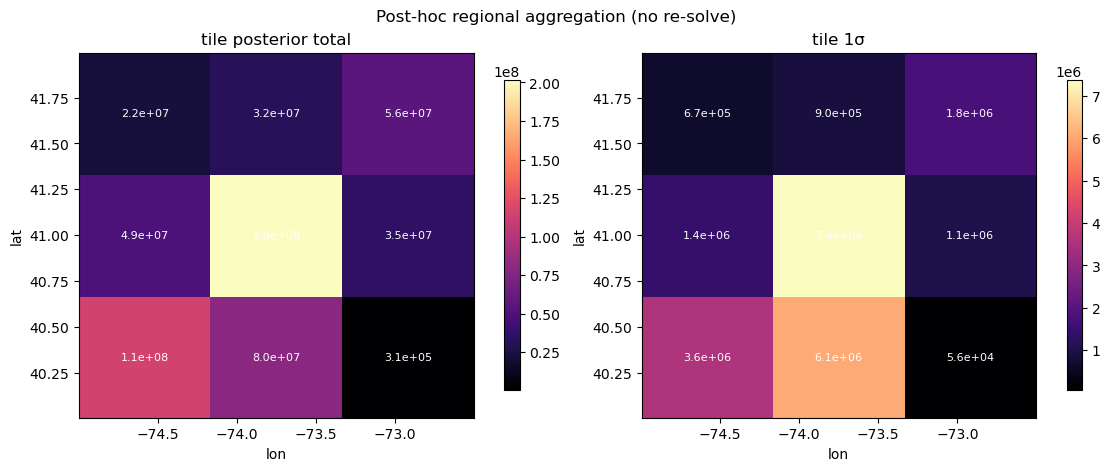

tiles sum to 5.9094e+08 vs domain total 5.9094e+08


In [10]:
# regional sub-totals: split the active domain into an NxN grid of tiles and
# aggregate each (with uncertainty) post-hoc
N = 3
alat, alon = core.active_lat, core.active_lon
lat_edges = np.linspace(alat.min(), alat.max()+1e-9, N+1)
lon_edges = np.linspace(alon.min(), alon.max()+1e-9, N+1)
rowsA = []
for i in range(N):
    for j in range(N):
        w = ((alat >= lat_edges[i]) & (alat < lat_edges[i+1]) &
             (alon >= lon_edges[j]) & (alon < lon_edges[j+1])).astype(float)
        rowsA.append(flux_functional(cell_weight=w))
means, cov = inv.estimate(np.array(rowsA))
tile_tot = means.reshape(N, N); tile_sd = np.sqrt(np.clip(np.diag(cov), 0, None)).reshape(N, N)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
ext = [lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]]
for a, (title, fld) in zip(ax, [('tile posterior total', tile_tot), ('tile 1\u03c3', tile_sd)]):
    im = a.imshow(fld, origin='lower', extent=ext, aspect='auto', cmap='magma')
    for i in range(N):
        for j in range(N):
            a.text((lon_edges[j]+lon_edges[j+1])/2, (lat_edges[i]+lat_edges[i+1])/2,
                   f'{fld[i,j]:.1e}', ha='center', va='center', color='w', fontsize=8)
    a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(im, ax=a, shrink=0.85)
plt.suptitle('Post-hoc regional aggregation (no re-solve)'); plt.show()
print(f'tiles sum to {tile_tot.sum():.4e} vs domain total {tot:.4e}')

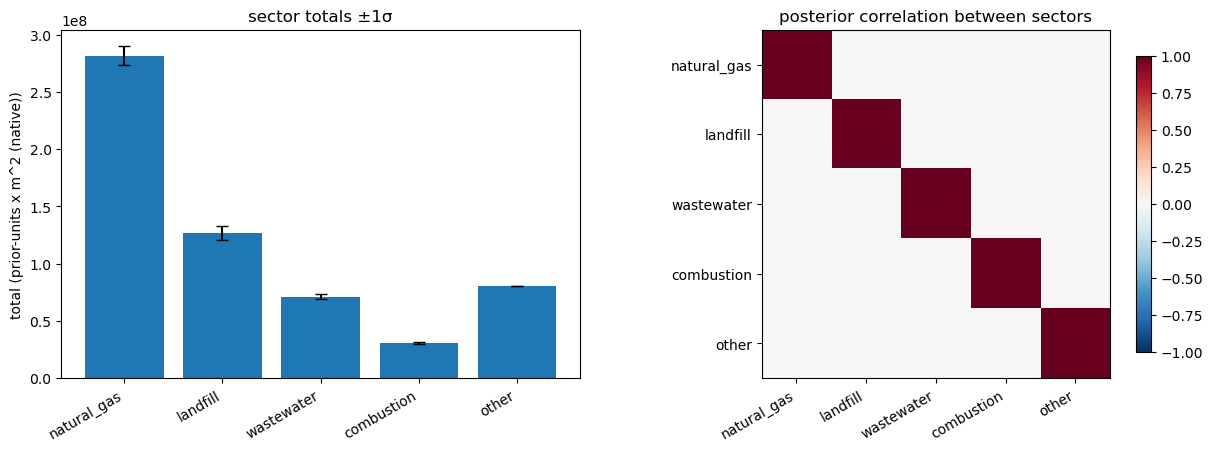

sector totals sum to 5.9094e+08 vs domain total 5.9094e+08


In [11]:
# sector totals + cross-covariance: aggregate each category block separately, so
# estimate() returns the full inter-sector covariance (not just per-sector sigma)
if len(gridded) > 1:
    A = np.array([flux_functional(blocks=[name]) for name in gridded])
    smeans, scov = inv.estimate(A)
    ssd = np.sqrt(np.clip(np.diag(scov), 0, None))
    corr = scov / np.outer(ssd, ssd)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
    x = np.arange(len(gridded))
    ax[0].bar(x, smeans, yerr=ssd, capsize=4)
    ax[0].set_xticks(x); ax[0].set_xticklabels(gridded, rotation=30, ha='right')
    ax[0].set_ylabel(f'total ({inv.report["unit_label"]})'); ax[0].set_title('sector totals \u00b11\u03c3')
    im = ax[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax[1].set_xticks(x); ax[1].set_xticklabels(gridded, rotation=30, ha='right')
    ax[1].set_yticks(x); ax[1].set_yticklabels(gridded)
    ax[1].set_title('posterior correlation between sectors'); fig.colorbar(im, ax=ax[1], shrink=0.85)
    plt.show()
    print('sector totals sum to', f'{smeans.sum():.4e}', 'vs domain total', f'{tot:.4e}')
else:
    print('single gridded block (total mode): sectors are obtained by post-hoc')
    print('variance partition - see halo_oe.decomposition.partition_by_prior_variance')

## Takeaways

Everything above came from the reloaded bundle alone — **no Jacobian, no re-solve**:

- `inv.field(name)` / `inv.block(name)` — posterior fields and block values; `posterior.stddev()` for uncertainty.
- `inv.receptors` — the full observation context (obs, background, enhancement, modeled, flight, outlier flag) for residual and QC analysis.
- `inv.estimate(A)` — the engine for post-hoc work: any linear functional's posterior **mean and full covariance**. Build `A` for a region (tiled), a sector (per category block), or any custom aggregation/disaggregation, and you get the answer with correct uncertainty, including cross-terms.
- `inv.group_fields` — the super-category prior fields, for re-grouping categories or a variance-weighted disaggregation.

Run the expensive inversion once with `--save`; explore the posterior as many ways as you like from the bundle.

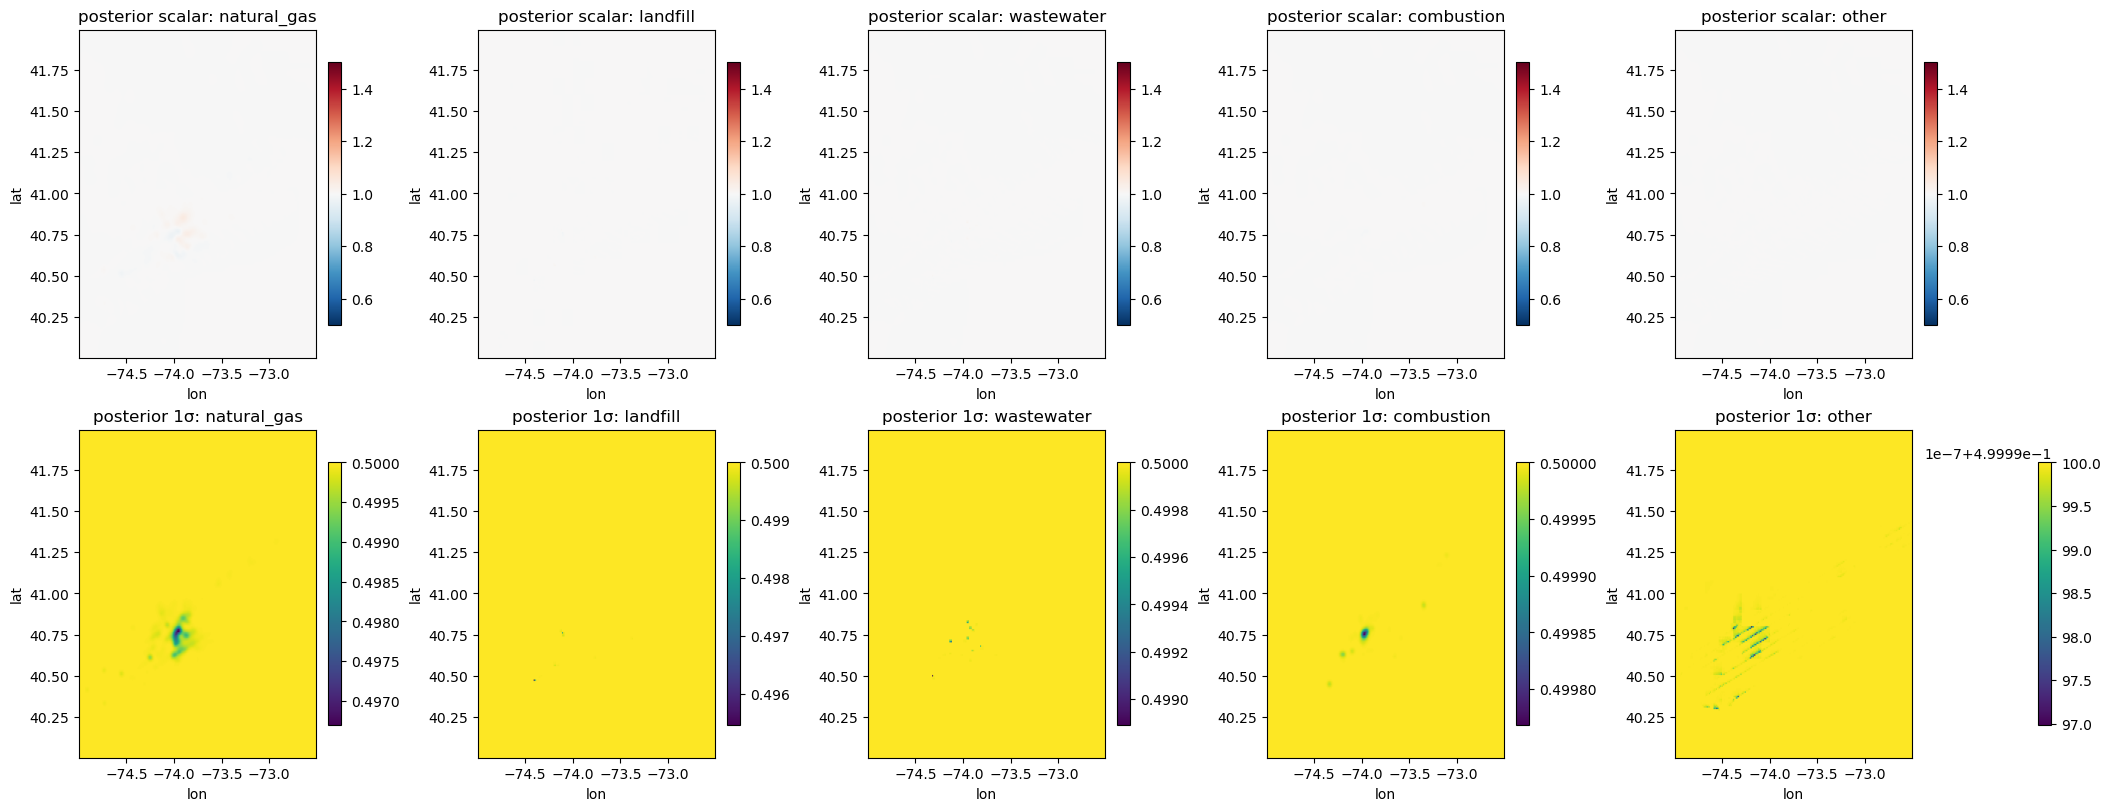

In [1]:
import os, sys, tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

BAYES_OPT = os.path.dirname(os.path.dirname(os.path.abspath('saved_bundle_analysis.ipynb')))
if BAYES_OPT not in sys.path:
    sys.path.insert(0, BAYES_OPT)
import halo_oe  # noqa: F401

from halo_oe.io_bundle import load_inversion
from halo_oe.flux import cell_areas_m2

# Set this to a real bundle directory (from `run_halo.py --save`) to analyze real
# results. Bundles now live under bayes_opt/runs/. If the path does not exist, a
# small synthetic bundle (with a buffer region) is built below.
BUNDLE_DIR = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg2'))

from halo_oe.plotting import plot_posterior
BUNDLE_DIR = os.environ.get('HALO_BUNDLE', os.path.join(BAYES_OPT, 'runs', 'bg_deg2'))
plot_posterior(load_inversion(BUNDLE_DIR), out_path=None)